# IA006 - Introduction to Brain-Computer Interfaces

## Activity 2 - BCI + SSVEP

Gustavo Freitas Alves

236249


In [ ]:
from google.colab import files

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import fractional_matrix_power

from concurrent.futures import ProcessPoolExecutor

from sklearn.cross_decomposition import CCA

from joblib import Parallel, delayed
from functools import lru_cache

[Exercice guide](https://doc-00-40-prod-01-apps-viewer.googleusercontent.com/viewer2/prod-01/pdf/g9lhuph2d5fb424sec7dfe25rkmgkkf2/rvflihgl9qho6egopjgfdak58btfadbn/1748735550000/3/106431237271870765137/APznzaaAUwxfrlC5JOTBg2-XqAHzkN3W2IHdPGvtRFDmsWAdlN-qLiopewyvKduedGPNUdXYGDnF31B_cIvbMt3S_RiSll-14VGuDA7XnoNzybl3x3lVyKhRU4ZOblUgb-4RA_dfgWNP8_oP5dTOAWyuJolaUQoLS39Mx6bIAxZoA5D5AWa4snPEWUPHnrufUoj17UH-urNxZ-uN7OoCDoMwsiRFMr0CtaOBA31xsvB_j22O2VSg_nVF0j5b9u3y-Q_4aHO9DcRnkjyxLmu0nklNLMC-gr2lhowbj2aQD0SbVUq7Bn6-YjVIQfQcffTe95tstWARnux00A9uiYCwhNa52noUuoLT36R8CQdv9U3rRPHFDdixTpnrwTUVG931mCzGaSCbVlOz7a783fTDUadZZtFyz-lQG83PZsXvXYRWv1i1gK8CgTn_Zq-oh8GUlRAJ8tD9uutXJArfe9xkXtvyt_GL_663aNyIuamp657Lj5UD-4egqynH1FlMyq-_F9EWFLbiEEWwjSiWYt47hRGzWB4ba1c6YzPFhlD3Ntqu5WOOeKTBG-RjPSYAykxRQq7XDAzOoksY8T8jZFQUcQ4_PWO545T0rwuOa4I1shw5HlccCc4hdkvPUkum8viey2jv3rS_93fK-I5XJ2W1mSBECtjIPPJHiV_TV18ZOyxONl4NlRow2O9akYejF1WVysvd6XjSHkDWvdzi-Ay8H7ERtywmLvoi63QEDoR5l9zLJHU1Cdz-yS383I0NDizgO9-gfaD2Q5p6yJhSYNqBiDnAKwP3DhFczv5ttapJQ8RkVSVfxfOMG_OQBIvncJrQNcVVzijs7ki4JPkuM6SNG4y6DBM57XpJYNi4SAhz_ASGZCenCK_B_5_pV5z9622eT1vgQl09yu8nZfdJzG1xViHAhkd3F4G4uhg5r_nDTJg4egWsVp-BK8uaJtlTZkXAPMv1j95S_fHCKI2RWYMVdDDMILMe1gyE3zbuOuKVKmvwU6Gks3pDoItKsVn0Xbx6yMB81MrRKxtR2lSEMx0ZlEBwycVvFfkgiFuouQZbbXp0P0HnWQ3XA6_Om8MZ-u5l7UUPyb-S30f3Y-aj3kKQW_02EQqtgxu5LgIxELdaZt40iAjeXWcqz-nwtXge7eSA5cbPEglhWHkWXm97DbNRmNSO0VapQ19kMZ36p4hujirIIe4tDaNkvlRjnhP1GI_tcyVd4hffgDnDivarJvHJtkaR2zUxnpobYV6cZFEuDHdDAIzp7teE60sgcnhgp6ucCMZ7gDQi_U-ECh-lTiJeV2NtCrthISkPxoDyxiQFhidZdlsWBesDU_mXECdUmZ7ROJVr2sr9eJL86Uhk8I5l5ng2tSs0d-0GdIIn04et7wNMvu1_dz3NZeHQfe2StexFCUTqA2_RG40_aOTV9eeRWSyyvavMxW4NFodxqk5L-RcopJQCfCkeKjBYwSZ5jjA0euU1rw7ChLfstIbO-rtO_H2oFT3mc2c26ViTreiS3qvHcDB8mTPg80lOVGyJnhl6iTUQXsEMzv-bgDbqiAgdyG7RV7kCpAJqZxAF2LJWQaGqLDOOd-vTEHETmKD5in8HXujiViOodZNfVVdPIr_qAwF7l6whyQzqugOndKYF2J5kz-0334321GZGIEjaEsDlUL2qslfy3qs_iTjuSvIJgsiNrXkOasNG67svTBYJB9MNO07DBsmfRpLK8cBLSlaTx0uAlqt5WtbHnd-NrLhlT3kmvqLBm8fAEFpmjD_pth5DaOL0iCQ6ORPW_JirdpBImGXso2SDrw7e9T-o0Arr5dh7gKdQrZZKSi8SqM9wAJnUC52uxVHUiW79Zi2caSPZWm2MDie7lB_fU0i5hOmKzBJ0hos-8NuE7BAuCpELSRNdQ5LM_7kYG48nDrksZEH6f01NbEqg5Ox9arNCHcqaV1tbv-wvvnnJTmeZHLKs1N3zS8XAdr3DmnoSAd0xyp6DIUUfcCowShd6AkhaqTFRWFVtwdiGFNQe8IvYOFz_G66EdeR_yD45k41R98vL1kt6qy0EC38bTTxJJP5XTVH9uW8dNsDhQUQmjg==?authuser=0&nonce=t54ui1bbcdoqg&user=106431237271870765137&hash=0jr4gkum0t4utb092btmma40atf8bt9j)

[Dataset](https://bci.med.tsinghua.edu.cn/download.html)

## Notes

* Usaremos a mesma base de dados do exercício 1

* Focar nos eletrodos da região occipital e proximidades (Pz, PO5, PO3, POz, PO4, PO6, O1, Oz e O2)

* Não é necessário aplicar filtragem passa-banda nos dados antes do processamento

### Janelamento EEG

Extrai apenas uma janela de cada trial (independente do tempo de duração). 240 janelas no total.

Janela deve começar em 0,64s  (0,5 do estímulo + 0,14 do tempo de reação)

### ITR (information transfer rate) [bits/min]

$$ITR = \left( \log_{2}(M) + P \log_{2} P + (1 - P) \log_{2} \left[ \frac{1 - P}{M - 1} \right] \right) \times \frac{60}{T}$$

* M = número de estímulos visuais presentes no sistema

* P = acurácia

* T = tempo necessário para a interface gerar um comando em segundos. Para o cálculo de T deve considerar o tempo necessário para o usuário mudar seu foco de atenção de um estímulo par ao próximo ($\textit{gaze shifting time}$) de 0,55 seg.

T = 0,55[s] + duração da janela[s]

---

## Data

In [ ]:
# Upload the data (this is so slowly)
upload_files = files.upload()

Saving S3.mat to S3.mat


In [ ]:
# Load the data for one subjtect
dataS3 = scipy.io.loadmat('S3.mat')

In [ ]:
# EEG data
eeg_signal_S3 = dataS3['data']
eeg_signal_S3.shape

(64, 1500, 40, 6)

In [ ]:
# Channels
_64_channels_loc = [
    [1, -18, 0.51111, 'FP1'],
    [2, 0, 0.51111, 'FPZ'],
    [3, 18, 0.51111, 'FP2'],
    [4, -23, 0.41111, 'AF3'],
    [5, 23, 0.41111, 'AF4'],
    [6, -54, 0.51111, 'F7'],
    [7, -49, 0.41667, 'F5'],
    [8, -39, 0.33333, 'F3'],
    [9, -22, 0.27778, 'F1'],
    [10, 0, 0.25556, 'FZ'],
    [11, 22, 0.27778, 'F2'],
    [12, 39, 0.33333, 'F4'],
    [13, 49, 0.41667, 'F6'],
    [14, 54, 0.51111, 'F8'],
    [15, -72, 0.51111, 'FT7'],
    [16, -69, 0.39444, 'FC5'],
    [17, -62, 0.27778, 'FC3'],
    [18, -45, 0.17778, 'FC1'],
    [19, 0, 0.12778, 'FCz'],
    [20, 45, 0.17778, 'FC2'],
    [21, 62, 0.27778, 'FC4'],
    [22, 69, 0.39444, 'FC6'],
    [23, 72, 0.51111, 'FT8'],
    [24, -90, 0.51111, 'T7'],
    [25, -90, 0.38333, 'C5'],
    [26, -90, 0.25556, 'C3'],
    [27, -90, 0.12778, 'C1'],
    [28, 90, 0, 'Cz'],
    [29, 90, 0.12778, 'C2'],
    [30, 90, 0.25556, 'C4'],
    [31, 90, 0.38333, 'C6'],
    [32, 90, 0.51111, 'T8'],
    [33, 90, 0.71111, 'M1'],
    [34, -108, 0.51111, 'TP7'],
    [35, -111, 0.39444, 'CP5'],
    [36, -118, 0.27778, 'CP3'],
    [37, -135, 0.17778, 'CP1'],
    [38, 180, 0.12778, 'CPZ'],
    [39, 135, 0.17778, 'CP2'],
    [40, 118, 0.27778, 'CP4'],
    [41, 111, 0.39444, 'CP6'],
    [42, 108, 0.51111, 'TP8'],
    [43, -90, 0.71111, 'M2'],
    [44, -126, 0.51111, 'P7'],
    [45, -131, 0.41667, 'P5'],
    [46, -141, 0.33333, 'P3'],
    [47, -158, 0.27778, 'P1'],
    [48, 180, 0.25556, 'PZ'],
    [49, 158, 0.27778, 'P2'],
    [50, 141, 0.33333, 'P4'],
    [51, 131, 0.41667, 'P6'],
    [52, 126, 0.51111, 'P8'],
    [53, -144, 0.51111, 'PO7'],
    [54, -144, 0.44722, 'PO5'],
    [55, -157, 0.41111, 'PO3'],
    [56, 180, 0.38333, 'POz'],
    [57, 157, 0.41111, 'PO4'],
    [58, 144, 0.44722, 'PO6'],
    [59, 144, 0.51111, 'PO8'],
    [60, -135, 0.72222, 'CB1'],
    [61, -162, 0.51111, 'O1'],
    [62, 180, 0.51111, 'Oz'],
    [63, 162, 0.51111, 'O2'],
    [64, 135, 0.72222, 'CB2'],
]

## Exercice

Frequências dos sinais

In [ ]:
_freqs_trials = np.arange(8, 16, 0.2)

In [ ]:
_channels_sel = [47, 53, 54, 55, 56, 57, 58, 60, 61, 62]

Subject 3

CCA

janela de 3s EEG

para todos os 40 estímulos

fundamental + 1 harmonica

### Janela de 3 segundos

Considerando apenas o eletrodo Oz com janela entre 0,64s e 3,64s, isso equivale a 160 a 910.

In [ ]:
def window(signal:np.ndarray, trial:int, channel:list=_channels_sel, size:tuple=(160, 910), block:int=None) -> np.ndarray:
  """
    Window function for EEG data
  """
  if block is not None:
    _signal = signal[channel, size[0]:size[1], trial, block]
  else:
    _signal = np.mean(signal[channel, size[0]:size[1], trial, :], axis=-1)
  return _signal

#### CCA

In [ ]:
def cca_func(X:np.ndarray, Y:np.ndarray, _verbose:bool=False):
  """
    Canonical correlation analysis (CCA) function
  """

  if X.shape[1] != Y.shape[1]:
    if _verbose: print('X and Y have different shapes. Changing X shape')
    X = X.T

  T = X.shape[1]

  # Remove mean value
  X = X - np.mean(X, axis=0, keepdims=True)
  Y = Y - np.mean(Y, axis=0, keepdims=True)

  # Covariance and variance matrices
  Cxy = (1/T) * X @ Y.T
  Cxx = (1/T) * X @ X.T
  Cyy = (1/T) * Y @ Y.T

  # Regularization (to converge)
  _reg = 1e-6
  Cxx += _reg * np.eye(Cxx.shape[0])
  Cyy += _reg * np.eye(Cyy.shape[0])

  # Matrix K
  K = fractional_matrix_power(Cxx, -0.5) @ Cxy @ fractional_matrix_power(Cyy, -0.5)

  # USV decomposition
  _, S, _ = np.linalg.svd(K)

  # Take the first lambda -> max correlation
  return np.sqrt(S[0])

In [ ]:
def cca_func_sklearn(eeg:np.ndarray, ref:np.ndarray) -> float:
  """
    Canonical correlation analysis (CCA) function using sklearn
  """
  eeg = eeg.T
  ref = ref.T

  cca = CCA(n_components=1)
  cca.fit(eeg, ref)

  U, V = cca.transform(eeg, ref)

  corr = np.corrcoef(U.T, V.T)[0, 1]

  return corr

In [ ]:
def reference_signals(freq:float, T:int, samprate:float, N:int=1, _verbose:bool=False) -> np.ndarray:
  """
    Reference signals function for N harmonics with T samples
  """
  if _verbose: print(f'Running reference signals for {freq=} | {T=} | {samprate=} | {N=}')

  n = np.arange(T) / samprate

  _ref = np.array([f((_n + 1) * 2 * np.pi * freq * n) for _n in range(N+1) for f in (np.sin, np.cos)])

  return _ref

### Item A

In [ ]:
_samp_rate = 250 # Hz
_n_samples = 750 # 3 seconds
_trial = -1 # trial selection
_block = 2

In [ ]:
rhos = np.zeros(len(_freqs_trials))
_eeg_signal = window(eeg_signal_S3, _trial, block=_block)
for i, f in enumerate(_freqs_trials):
  _ref = reference_signals(f, _n_samples, _samp_rate)
  _cca = cca_func(_eeg_signal, _ref)
  rhos[i] = _cca

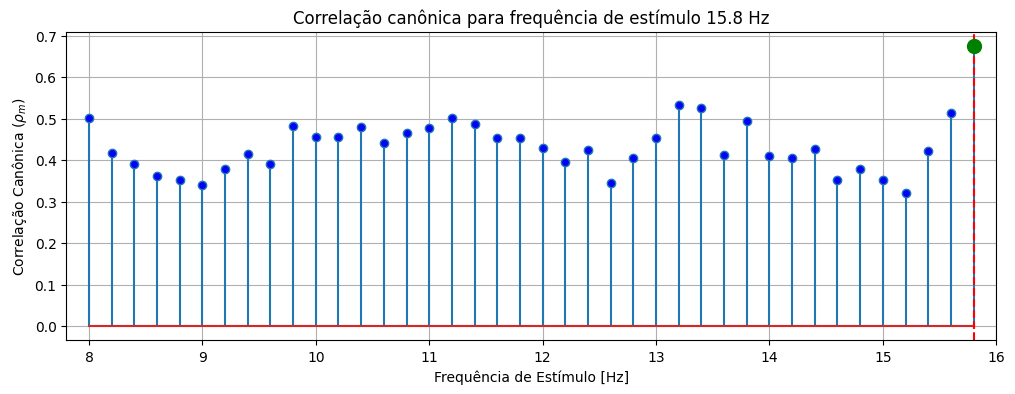

In [ ]:
plt.figure(figsize=(12,4))
markerline, stemlines, baseline = plt.stem(_freqs_trials, rhos)
plt.setp(markerline, 'markerfacecolor', 'b')
plt.xlabel('Frequência de Estímulo [Hz]')
plt.ylabel('Correlação Canônica (${\\rho}_m$)')
plt.axvline(x=_freqs_trials[_trial], color='r', linestyle='--')
plt.scatter(_freqs_trials[np.argmax(rhos)], rhos[np.argmax(rhos)], color='g', s=100, zorder=5)
plt.title(f'Correlação canônica para frequência de estímulo {_freqs_trials[_trial]:.1f} Hz')
plt.xlim(_freqs_trials[0]-0.2, _freqs_trials[-1]+0.2)
plt.grid()
plt.show()

In [ ]:
rhos = np.zeros(len(_freqs_trials))
_eeg_signal = window(eeg_signal_S3, _trial, block=_block)

for i, f in enumerate(_freqs_trials):
  _ref = reference_signals(f, _n_samples, _samp_rate)
  _cca = cca_func_sklearn(_eeg_signal, _ref)
  rhos[i] = _cca

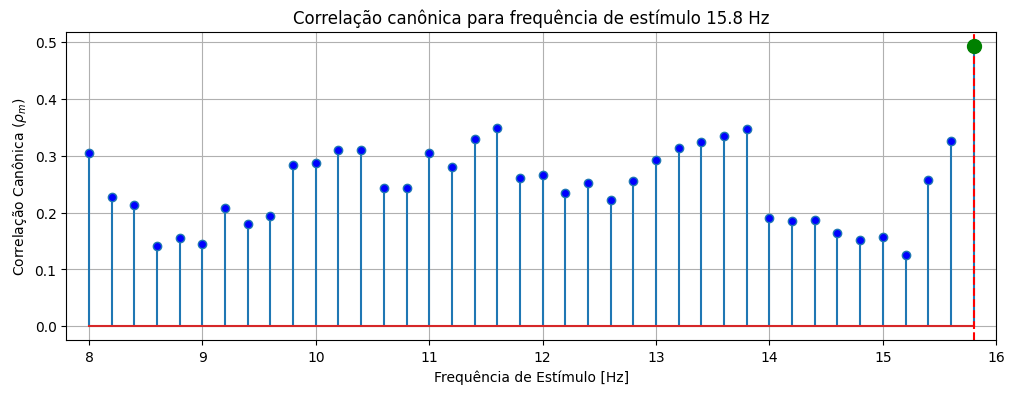

In [ ]:
plt.figure(figsize=(12,4))
markerline, stemlines, baseline = plt.stem(_freqs_trials, rhos)
plt.setp(markerline, 'markerfacecolor', 'b')
plt.xlabel('Frequência de Estímulo [Hz]')
plt.ylabel('Correlação Canônica (${\\rho}_m$)')
plt.axvline(x=_freqs_trials[_trial], color='r', linestyle='--')
plt.scatter(_freqs_trials[np.argmax(rhos)], rhos[np.argmax(rhos)], color='g', s=100, zorder=5)
plt.title(f'Correlação canônica para frequência de estímulo {_freqs_trials[_trial]:.1f} Hz')
plt.xlim(_freqs_trials[0]-0.2, _freqs_trials[-1]+0.2)
plt.grid()
plt.show()

Os únicos pontos que obtivemos a maior correlação canônica foram com 8Hz e 15,8Hz, sendo que o caso que aprenseta maior correlação é para a frequência de estímulo de 8 Hz.



### Item B

CCA não-supervisionado (FBCCA)

Acurácia e ITR

voluntário 3

janela de 0,5s a 5s com incrementos de 0,25s

varies o número de harmônicas (0, 1, 2, 3, 4, 5)

obter acurácia para as 240 janelas (trials e blocos)

n_acertos/240

Olhar fig 5 do artigo do dataset

In [ ]:
def itr_func(_m:int, _p:float, _t:float) -> float:

  if _p <= 0:
    return 0.0

  T = 0.55 + _t

  _itr0 = np.log2(_m)
  _itr1 = _p * np.log2(_p) if _p > 0 else 0
  _itr2 = (1 - _p) * np.log2((1 - _p)/(_m - 1)) if _p < 1 else 0

  _itr = (_itr0 + _itr1 + _itr2) * 60 / T

  return _itr

In [ ]:
# Janela (deve variar de 0,5s a 5s)
_window_size_start = 160 # 0,64s
_window_size_inc = 62 # aproximadamente 0,25s

In [ ]:
max_harmonics = 1

In [ ]:
acc = []
ITR = []

Pré-computar as janelas

In [ ]:
eeg_windows = {}
for _window_end in range(_window_size_start + _window_size_inc, 1500, _window_size_inc):
  for trial in range(40):
    for block in range(6):
      eeg_windows[(trial, block, _window_end)] = window(
          eeg_signal_S3, trial, size=(_window_size_start, _window_end), block=block
          )

In [ ]:
for n_har in range(max_harmonics + 1):
  _acc = []
  _ITR = []

  for _window_end in range(_window_size_start + _window_size_inc, 1500, _window_size_inc):

    _n_samples = _window_end - _window_size_start

    ref_signals_dict = {
        f: reference_signals(f, _n_samples, _samp_rate, n_har) for f in _freqs_trials
    }

    n_rights = 0

    for trial in range(40):
      freq = _freqs_trials[trial]

      for block in range(6):
        _eeg_signal = eeg_windows[(trial, block, _window_end)]

        # # paralelizar cálculos
        # with ProcessPoolExecutor() as executor:
        #   futures = [
        #       executor.submit(cca_func, _eeg_signal, ref_signals_dict[f])
        #       for f in _freqs_trials
        #   ]
        #   rhos = [future.result() for future in futures]

        rhos = [cca_func(eeg_windows[((trial, block, _window_end))], ref_signals_dict[f]) for f in _freqs_trials]

        pred = _freqs_trials[np.argmax(rhos)]

        if pred == freq:
          n_rights += 1

    accuracy = n_rights/240
    _acc.append(accuracy)
    _ITR.append(itr_func(240, accuracy, _window_end/_samp_rate))

  acc.append(_acc)
  ITR.append(_ITR)

In [ ]:
ITR

[[np.float64(2.442714085198741),
  np.float64(3.037162934535568),
  np.float64(2.6477025375527234),
  np.float64(3.1531669361370844),
  np.float64(1.7678107959400362),
  np.float64(1.6041001621113846),
  np.float64(2.0448493037951985),
  np.float64(2.4602597305641294),
  np.float64(1.7484596910884722),
  np.float64(1.6303076465680522),
  np.float64(1.9930741155718599),
  np.float64(1.6515147034688231),
  np.float64(1.7691129100159828),
  np.float64(1.4758065754292402),
  np.float64(1.2185802572107436),
  np.float64(0.8328383548147127),
  np.float64(0.794631933802125),
  np.float64(0.7597771903314976),
  np.float64(0.7278516154073683),
  np.float64(0.5711581877261448),
  np.float64(0.671425482046622)]]

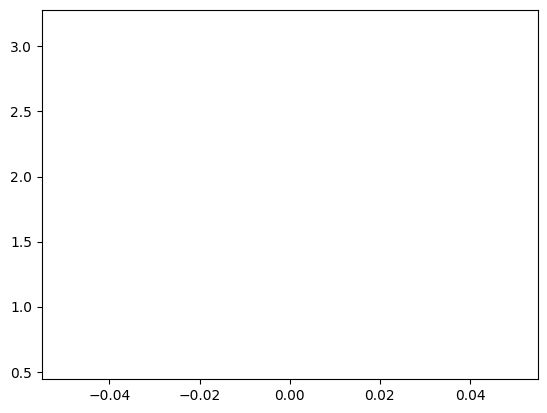

In [ ]:
# x = np.arange(0, 6,)
# plt.plot(acc)
plt.plot(ITR)
# plt.grid()
plt.show()

### Verificando:

In [ ]:
# Cache para as referências
@lru_cache(maxsize=None)
def reference_signals_cached(freq, T, samp_rate, N):
    return reference_signals(freq, T, samp_rate, N)

In [ ]:
acc = []
ITR = []

In [ ]:
# Pré-calcular janelas de EEG
eeg_windows = {}
window_ends = range(_window_size_start + _window_size_inc, 1500, _window_size_inc)
for _window_end in window_ends:
    for trial in range(40):
        for block in range(6):
            eeg_windows[(trial, block, _window_end)] = window(
                eeg_signal_S3, trial, size=(_window_size_start, _window_end), block=block
            )

In [ ]:
# Loop sobre número de harmônicas
for n_har in range(max_harmonics + 1):
    _acc = []
    _ITR = []

    for _window_end in window_ends:
        _n_samples = _window_end - _window_size_start

        # Gera referências para todas as frequências
        ref_signals_dict = {
            f: reference_signals_cached(f, _n_samples, _samp_rate, n_har)
            for f in _freqs_trials
        }

        # Função de classificação para cada (trial, block)
        def classify(trial, block):
            _eeg_signal = eeg_windows[(trial, block, _window_end)]
            rhos = [cca_func_sklearn(_eeg_signal, ref_signals_dict[f]) for f in _freqs_trials]
            pred = _freqs_trials[np.argmax(rhos)]
            true_freq = _freqs_trials[trial]
            return int(pred == true_freq)

        # Paralelizar
        results = Parallel(n_jobs=-1, prefer="processes")(
            delayed(classify)(trial, block)
            for trial in range(40)
            for block in range(6)
        )

        n_rights = sum(results)
        accuracy = n_rights / 240
        _acc.append(accuracy)
        _ITR.append(itr_func(240, accuracy, _window_end / _samp_rate))

    acc.append(_acc)
    ITR.append(_ITR)

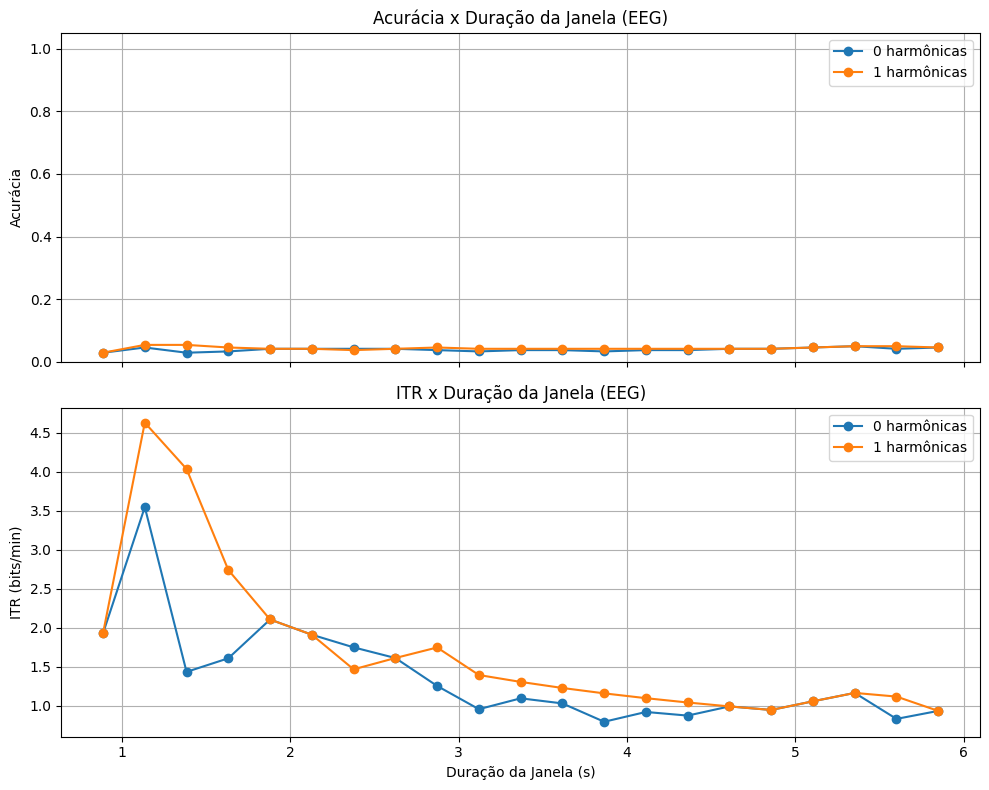

In [ ]:
# Suponha que o _window_size_inc seja em número de amostras
window_durations_sec = np.array(window_ends) / _samp_rate  # Convertendo para segundos
harmonics_labels = [f'{n} harmônicas' for n in range(max_harmonics + 1)]

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# -------- Plot da Acurácia --------
for idx, _acc in enumerate(acc):
    axs[0].plot(window_durations_sec, _acc, marker='o', label=harmonics_labels[idx])

axs[0].set_title('Acurácia x Duração da Janela (EEG)')
axs[0].set_ylabel('Acurácia')
axs[0].grid(True)
axs[0].legend()
axs[0].set_ylim(0, 1.05)

# -------- Plot do ITR --------
for idx, _ITR in enumerate(ITR):
    axs[1].plot(window_durations_sec, _ITR, marker='o', label=harmonics_labels[idx])

axs[1].set_title('ITR x Duração da Janela (EEG)')
axs[1].set_xlabel('Duração da Janela (s)')
axs[1].set_ylabel('ITR (bits/min)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

### Item C

Faço o mesmo para o voluntário 21